# Lattice and Kronecker Methods

In [2]:
from qmcpy import *
import numpy as np
from matplotlib import pyplot
from time import time
np.set_printoptions(legacy='1.25')

## Discrepancy Values

#### Lattice

In [4]:
dim = 50
n = 2**20
lat = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12) # initialize a lattice as usual
coord_weights = np.array([j**(-2) for j in range(1, dim + 1)]) # define some coordinate weights

lat_discs = lat.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights) # compute the expected squared periodic discrepancies for n = 1, 2, ...

sample_weights = np.arange(1, n+1) # define some sample weights
lat_wssd = lat.wssd(n_max=n, coord_weights=coord_weights, sample_weights=sample_weights) # compute the wssd

#### Kronecker

In [5]:
kron = Kronecker(dimension=dim, seed=12) # initialize a Kronecker sequence as usual
kron_k_tilde = (lambda x, gamma: np.prod(1 + (x * (x - 1) + 1/6) * gamma, axis=-1), 1) # define the kernel function (in this case, the second Bernoulli polynomial)

kron_discs = kron._square_periodic_discrepancies(n = n, k_tilde = kron_k_tilde, gamma = coord_weights) # compute the expected squared periodic discrepancies for n = 1, 2, ...

kron_wssd = kron.wssd_discrepancy(n = n, weights = sample_weights, k_tilde = kron_k_tilde, gamma = coord_weights) # compute the wssd

C:\Users\headw\QMCSoftware\qmcpy\discrete_distribution\kronecker\kronecker.py:276: RuntimeWarning: CBC generating vector only supports dimension <= 13; falling back to Richtmyer.
  warnings.warn(


## Searches

#### Lattice

In [5]:
from qmcpy.discrete_distribution.lattice.lattice_vector_wssd_search import lattice_vector_wssd_search

# note that the search requires that the sample weights be w_n = n, so they are not customizable

time_start = time()
searched_lattice_vector = lattice_vector_wssd_search(N = n, d = dim, kernel = lambda x: x * (x - 1) + 1 / 6, coord_weights = coord_weights) # search for a lattice vector with low wssd
time_end = time()
print("Time taken for lattice vector wssd search: ", time_end - time_start)
print("Searched lattice vector: ", searched_lattice_vector)

Time taken for lattice vector wssd search:  8.519208669662476
Searched lattice vector:  [     1 444567 406809  53917 411513 111013  57773  23363 278133 179399
 145725 480145 365723 134199 361515 297163 315729 250703 322429 236947
 508553 455183 148433  37975  46187 474063 490317  14811 417263 342641
 474417 269197 309749  29993 366775 433399 240621 375377  84847 232327
 214987 375079  32109 388283 153487 140919 390453 362317 413527 405689]


#### Kronecker

In [ ]:
from qmcpy.discrete_distribution.kronecker.kronecker_search_methods import kronecker_search_march_2026

searchsize = 25 # the time cost is  O(dim * N * searchsize^2), so searchsize should be chosen with care. The largest I have run was in MATLAB with searchsize = 300, N = 2^20, d = 100, which took about 24 hours 

# note that the search requires that the sample weights be w_n = n, so they are not customizable

time_start = time()
searched_kron_vector = kronecker_search_march_2026(N = n, dMax = dim, kernel = lambda x: x * (x - 1) + 1 / 6, searchsize = searchsize, coord_weights = coord_weights) # search for a Kronecker vector with low wssd
time_end = time()

print("Time taken for Kronecker vector wssd search: ", time_end - time_start)
print("Searched Kronecker vector: ", searched_kron_vector)

## Plotting

Text(0, 0.5, 'Periodic Discrepancy')

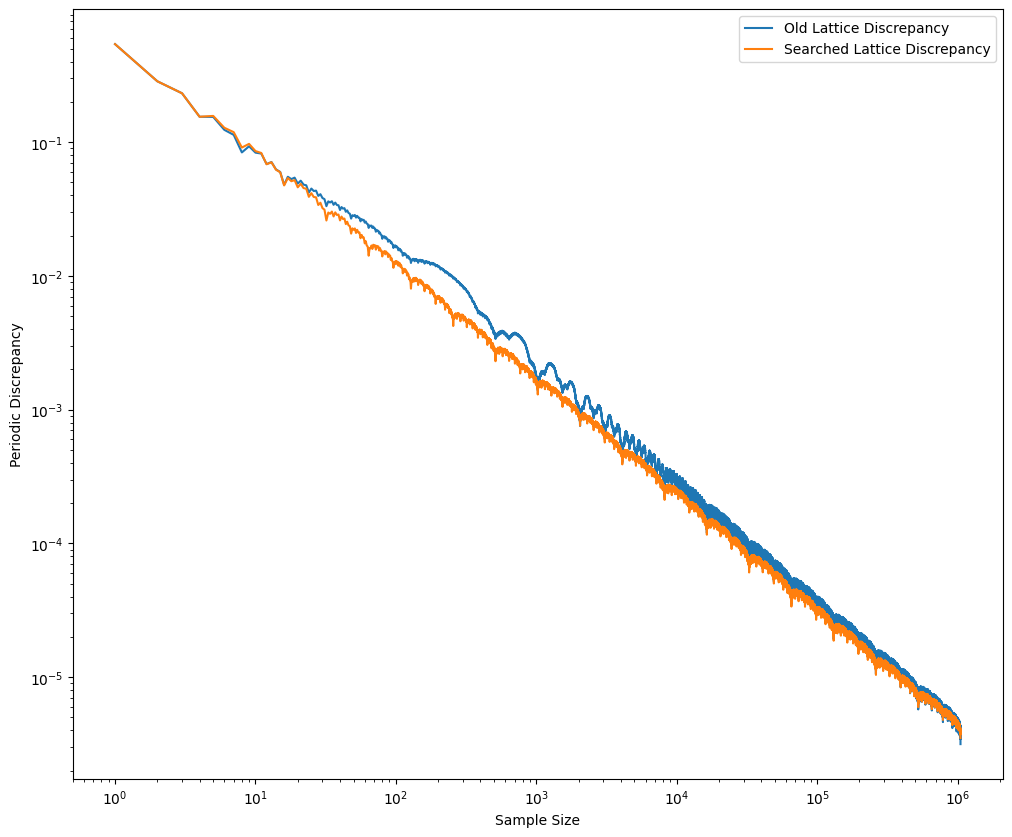

In [ ]:
gen_vec = np.loadtxt("kuo.lattice-39102-1024-1048576.3600.txt",dtype=np.uint64) 
lat1 = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12, generating_vector=gen_vec[:,1], m_max=20) # initialize a lattice with the generating vector of all 1s
lat_discs1 = lat1.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights)


lat2 = Lattice(dimension=dim, order="RADICAL_INVERSE", seed=12, generating_vector=np.uint64(searched_lattice_vector), m_max=20) # initialize a lattice with the searched lattice vector
lat_discs2 = lat2.expected_squared_periodic_discrepancies(n_max=n, coord_weights=coord_weights)


fig, ax = pyplot.subplots(nrows=1, ncols=1, figsize=(12,10))
ax.plot(np.arange(1, n+1), np.sqrt(lat_discs1), label="Kuo Lattice Discrepancy")
ax.plot(np.arange(1, n+1), np.sqrt(lat_discs2), label="New Lattice Discrepancy")
# ax.plot(np.arange(1, n+1), np.sqrt(kron_discs), label="Kronecker Discrepancy")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Sample Size")
ax.set_ylabel("Periodic Discrepancy")